Data loader code

In [623]:
# ============================================
# Cell 1: imports and config
# ============================================
import os
import glob
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

DATA_ROOT = "hand_dummy/data"

VIDEO_INPUT_ENABLED = False
BODY_POSE_INPUT_ENABLED = False
HAND_POSE_INPUT_ENABLED = True

LABELS = ["go", "stop", "left", "right", "null"]

# Use None to keep all 17 body landmarks
BODY_LANDMARK_USED = [5, 6,7,  8,9, 10,11,12]

BATCH_SIZE = 16
NUM_WORKERS = 0
VIDEO_SIZE = (112, 112)   # (W, H)
VIDEO_NORMALIZE = True

# --------------------------------------------
# Fixed padded lengths for each modality
# --------------------------------------------
VIDEO_PAD_LENGTH = 64   # final video shape: [64, C, H, W]
BODY_PAD_LENGTH = 64    # final body shape:  [64, K, 2]
HAND_PAD_LENGTH = 64    # final hand shape:  [64, 21, 2]

# If True, samples longer than target length are truncated
TRUNCATE_IF_LONGER = True

# Screening
REQUIRE_ALL_THREE_COMPONENTS = True
VERBOSE_SCREENING = True

In [624]:
# ============================================
# Cell 2: helpers
# ============================================
LABEL_TO_IDX = {name: i for i, name in enumerate(LABELS)}
IDX_TO_LABEL = {i: name for name, i in LABEL_TO_IDX.items()}


def apply_body_landmark_selection(body_np, landmark_indices=None):
    if landmark_indices is None:
        return body_np
    return body_np[:, landmark_indices, :]


def check_video_readable(video_path):
    if not os.path.isfile(video_path):
        return False, "video file missing"

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return False, "video cannot be opened"

    ret, frame = cap.read()
    cap.release()

    if not ret or frame is None:
        return False, "video has no readable frames"

    return True, None


def check_npy_shape(npy_path, expected_num_landmarks, name):
    """
    expected shape: [N, expected_num_landmarks, 2]
    """
    if not os.path.isfile(npy_path):
        return False, None, f"{name} file missing"

    try:
        arr = np.load(npy_path)
    except Exception as e:
        return False, None, f"{name} npy load failed: {e}"

    if arr.ndim != 3:
        return False, arr.shape, f"{name} ndim should be 3, got {arr.ndim}"

    if arr.shape[1] != expected_num_landmarks:
        return False, arr.shape, f"{name} landmark count should be {expected_num_landmarks}, got {arr.shape[1]}"

    if arr.shape[2] != 2:
        return False, arr.shape, f"{name} last dim should be 2, got {arr.shape[2]}"

    if arr.shape[0] <= 0:
        return False, arr.shape, f"{name} has zero length"

    return True, arr.shape, None


def load_video_cv2(video_path, target_size=(224, 224), normalize=True):
    """
    Returns video tensor of shape [T, C, H, W]
    """
    cap = cv2.VideoCapture(video_path)
    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, target_size)
        frame = torch.from_numpy(frame).float()  # [H, W, C]

        if normalize:
            frame = frame / 255.0

        frame = frame.permute(2, 0, 1)  # [C, H, W]
        frames.append(frame)

    cap.release()

    if len(frames) == 0:
        raise ValueError(f"Could not read frames from video: {video_path}")

    return torch.stack(frames, dim=0)  # [T, C, H, W]


def pad_or_truncate_tensor(x, target_len):
    """
    x shape: [T, ...]
    output shape: [target_len, ...]
    """
    cur_len = x.shape[0]

    if cur_len == target_len:
        return x

    if cur_len > target_len:
        return x[:target_len] if TRUNCATE_IF_LONGER else x

    pad_shape = (target_len - cur_len,) + tuple(x.shape[1:])
    pad_tensor = torch.zeros(pad_shape, dtype=x.dtype)
    return torch.cat([x, pad_tensor], dim=0)

In [625]:
# ============================================
# Cell 3: dataset with screening + fixed-length padding
# ============================================
class GestureEpisodeDataset(Dataset):
    def __init__(
        self,
        data_root,
        labels,
        video_input_enabled=True,
        body_pose_input_enabled=True,
        hand_pose_input_enabled=True,
        body_landmark_used=None,
        video_size=(224, 224),
        video_normalize=True,
        video_pad_length=None,
        body_pad_length=None,
        hand_pad_length=None,
        require_all_three_components=True,
        verbose_screening=True,
    ):
        self.data_root = data_root
        self.labels = labels
        self.video_input_enabled = video_input_enabled
        self.body_pose_input_enabled = body_pose_input_enabled
        self.hand_pose_input_enabled = hand_pose_input_enabled
        self.body_landmark_used = body_landmark_used
        self.video_size = video_size
        self.video_normalize = video_normalize
        self.video_pad_length = video_pad_length
        self.body_pad_length = body_pad_length
        self.hand_pad_length = hand_pad_length
        self.require_all_three_components = require_all_three_components
        self.verbose_screening = verbose_screening

        self.label_to_idx = {name: i for i, name in enumerate(labels)}

        if not (self.video_input_enabled or self.body_pose_input_enabled or self.hand_pose_input_enabled):
            raise ValueError("At least one input modality must be enabled.")

        self.samples = self._build_index()

        if len(self.samples) == 0:
            raise ValueError("No valid samples found after screening.")

    def _screen_one_sample(self, body_path, hand_path, video_path):
        reasons = []

        if self.require_all_three_components:
            if not os.path.isfile(body_path):
                reasons.append("missing body file")
            if not os.path.isfile(hand_path):
                reasons.append("missing hand file")
            if not os.path.isfile(video_path):
                reasons.append("missing video file")
            if reasons:
                return False, reasons
        else:
            if self.body_pose_input_enabled and not os.path.isfile(body_path):
                reasons.append("missing body file")
            if self.hand_pose_input_enabled and not os.path.isfile(hand_path):
                reasons.append("missing hand file")
            if self.video_input_enabled and not os.path.isfile(video_path):
                reasons.append("missing video file")
            if reasons:
                return False, reasons

        check_body = self.require_all_three_components or self.body_pose_input_enabled
        check_hand = self.require_all_three_components or self.hand_pose_input_enabled
        check_video = self.require_all_three_components or self.video_input_enabled

        if check_body:
            ok, shape, reason = check_npy_shape(body_path, 17, "body")
            if not ok:
                reasons.append(reason if reason is not None else f"invalid body shape: {shape}")

        if check_hand:
            ok, shape, reason = check_npy_shape(hand_path, 21, "hand")
            if not ok:
                reasons.append(reason if reason is not None else f"invalid hand shape: {shape}")

        if check_video:
            ok, reason = check_video_readable(video_path)
            if not ok:
                reasons.append(reason)

        if reasons:
            return False, reasons

        return True, None

    def _build_index(self):
        samples = []
        skipped = []

        for class_name in self.labels:
            class_dir = os.path.join(self.data_root, class_name)
            if not os.path.isdir(class_dir):
                skipped.append((class_name, "class folder missing"))
                continue

            all_session_prefixes = set()
            for path in glob.glob(os.path.join(class_dir, "session_*_body.npy")):
                all_session_prefixes.add(os.path.basename(path).replace("_body.npy", ""))
            for path in glob.glob(os.path.join(class_dir, "session_*_hand.npy")):
                all_session_prefixes.add(os.path.basename(path).replace("_hand.npy", ""))
            for path in glob.glob(os.path.join(class_dir, "session_*.mp4")):
                all_session_prefixes.add(os.path.basename(path).replace(".mp4", ""))

            for base in sorted(all_session_prefixes):
                body_path = os.path.join(class_dir, f"{base}_body.npy")
                hand_path = os.path.join(class_dir, f"{base}_hand.npy")
                video_path = os.path.join(class_dir, f"{base}.mp4")

                ok, reasons = self._screen_one_sample(body_path, hand_path, video_path)

                if not ok:
                    skipped.append((f"{class_name}/{base}", "; ".join(reasons)))
                    continue

                samples.append({
                    "label_name": class_name,
                    "label_idx": self.label_to_idx[class_name],
                    "body_path": body_path,
                    "hand_path": hand_path,
                    "video_path": video_path,
                    "session_id": base,
                })

        if self.verbose_screening:
            print(f"Valid samples: {len(samples)}")
            print(f"Skipped samples: {len(skipped)}")
            if len(skipped) > 0:
                print("\nSome skipped samples:")
                for item, reason in skipped[:30]:
                    print(f"  - {item}: {reason}")
                if len(skipped) > 30:
                    print(f"  ... and {len(skipped) - 30} more")

        self.skipped_samples = skipped
        return samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample_info = self.samples[idx]
        outputs = []

        body_input_shape = None

        if self.video_input_enabled:
            video = load_video_cv2(
                sample_info["video_path"],
                target_size=self.video_size,
                normalize=self.video_normalize,
            )  # [T, C, H, W]

            if self.video_pad_length is not None:
                video = pad_or_truncate_tensor(video, self.video_pad_length)

            outputs.append(video)

        if self.body_pose_input_enabled:
            body = np.load(sample_info["body_path"]).astype(np.float32)  # [T,17,2]
            body = apply_body_landmark_selection(body, self.body_landmark_used)
            body = torch.from_numpy(body)  # [T,K,2]

            if self.body_pad_length is not None:
                body = pad_or_truncate_tensor(body, self.body_pad_length)

            body_input_shape = tuple(body.shape)
            outputs.append(body)

        if self.hand_pose_input_enabled:
            hand = np.load(sample_info["hand_path"]).astype(np.float32)  # [T,21,2]
            hand = torch.from_numpy(hand)

            if self.hand_pad_length is not None:
                hand = pad_or_truncate_tensor(hand, self.hand_pad_length)

            outputs.append(hand)

        if self.body_pose_input_enabled:
            outputs.append(body_input_shape)

        label = torch.tensor(sample_info["label_idx"], dtype=torch.long)
        return tuple(outputs), label, sample_info["session_id"]

In [626]:
# ============================================
# Cell 4: collate fn
# ============================================
def gesture_collate_fn(batch):

    inputs_list = [item[0] for item in batch]
    labels = torch.stack([item[1] for item in batch], dim=0)
    session_ids = [item[2] for item in batch]
    return inputs_list, labels, session_ids

In [627]:
# ============================================
# Cell 5: create dataset and dataloader
# ============================================
dataset = GestureEpisodeDataset(
    data_root=DATA_ROOT,
    labels=LABELS,
    video_input_enabled=VIDEO_INPUT_ENABLED,
    body_pose_input_enabled=BODY_POSE_INPUT_ENABLED,
    hand_pose_input_enabled=HAND_POSE_INPUT_ENABLED,
    body_landmark_used=BODY_LANDMARK_USED,
    video_size=VIDEO_SIZE,
    video_normalize=VIDEO_NORMALIZE,
    video_pad_length=VIDEO_PAD_LENGTH,
    body_pad_length=BODY_PAD_LENGTH,
    hand_pad_length=HAND_PAD_LENGTH,
    require_all_three_components=REQUIRE_ALL_THREE_COMPONENTS,
    verbose_screening=VERBOSE_SCREENING,
)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=gesture_collate_fn,
)

print(f"Final usable sample count: {len(dataset)}")

Valid samples: 500
Skipped samples: 14

Some skipped samples:
  - go/session_0015: hand landmark count should be 21, got 0
  - go/session_0016: hand landmark count should be 21, got 0
  - go/session_0017: hand landmark count should be 21, got 0
  - go/session_0042: hand landmark count should be 21, got 0
  - go/session_0043: hand landmark count should be 21, got 0
  - go/session_0068: hand landmark count should be 21, got 0
  - go/session_0069: hand landmark count should be 21, got 0
  - go/session_0070: hand landmark count should be 21, got 0
  - go/session_0072: hand landmark count should be 21, got 0
  - go/session_0073: missing video file
  - left/session_0005: hand landmark count should be 21, got 0
  - left/session_0033: body landmark count should be 17, got 0; hand landmark count should be 21, got 0
  - left/session_0103: hand landmark count should be 21, got 0
  - left/session_0105: hand landmark count should be 21, got 0
Final usable sample count: 500


In [628]:
# ============================================
# Cell 6: inspect one batch
# ============================================
inputs_list, labels, session_ids = next(iter(loader))

print("Batch size:", len(inputs_list))
print("Labels:", labels)
print("Session IDs:", session_ids)

for i, sample_inputs in enumerate(inputs_list):
    print(f"\n--- Sample {i} ---")
    for j, x in enumerate(sample_inputs):
        if torch.is_tensor(x):
            print(f"item {j}: tensor shape = {tuple(x.shape)}")
        else:
            print(f"item {j}: {x}")

Batch size: 16
Labels: tensor([4, 2, 1, 3, 4, 4, 1, 1, 4, 2, 2, 0, 3, 2, 3, 1])
Session IDs: ['session_0058', 'session_0016', 'session_0087', 'session_0084', 'session_0077', 'session_0064', 'session_0000', 'session_0056', 'session_0078', 'session_0050', 'session_0012', 'session_0060', 'session_0100', 'session_0011', 'session_0031', 'session_0005']

--- Sample 0 ---
item 0: tensor shape = (64, 21, 2)

--- Sample 1 ---
item 0: tensor shape = (64, 21, 2)

--- Sample 2 ---
item 0: tensor shape = (64, 21, 2)

--- Sample 3 ---
item 0: tensor shape = (64, 21, 2)

--- Sample 4 ---
item 0: tensor shape = (64, 21, 2)

--- Sample 5 ---
item 0: tensor shape = (64, 21, 2)

--- Sample 6 ---
item 0: tensor shape = (64, 21, 2)

--- Sample 7 ---
item 0: tensor shape = (64, 21, 2)

--- Sample 8 ---
item 0: tensor shape = (64, 21, 2)

--- Sample 9 ---
item 0: tensor shape = (64, 21, 2)

--- Sample 10 ---
item 0: tensor shape = (64, 21, 2)

--- Sample 11 ---
item 0: tensor shape = (64, 21, 2)

--- Sample 

In [629]:
# ============================================
# Optional Cell 7: stacked collate fn
# ============================================
def gesture_collate_fn_stacked(batch):
    labels = torch.stack([item[1] for item in batch], dim=0)
    session_ids = [item[2] for item in batch]

    sample0 = batch[0][0]
    num_items = len(sample0)

    collated_inputs = []

    for item_idx in range(num_items):
        values = [sample[0][item_idx] for sample in batch]

        if torch.is_tensor(values[0]):
            collated_inputs.append(torch.stack(values, dim=0))
        else:
            collated_inputs.append(values)

    return tuple(collated_inputs), labels, session_ids

In [630]:
# ============================================
# Cell 7: train / val / test split
# ============================================
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset


# -------------------------
# Split ratios
# -------------------------
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

RANDOM_SEED = 42
STRATIFY_SPLIT = True

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-8


def make_train_val_test_subsets(
    dataset,
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15,
    random_seed=42,
    stratify_split=True,
):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-8

    indices = list(range(len(dataset)))
    labels = [dataset.samples[i]["label_idx"] for i in indices]

    stratify_labels = labels if stratify_split else None

    # First split: train vs temp
    train_indices, temp_indices = train_test_split(
        indices,
        test_size=(1.0 - train_ratio),
        random_state=random_seed,
        stratify=stratify_labels,
    )

    # Second split: val vs test from temp
    temp_labels = [dataset.samples[i]["label_idx"] for i in temp_indices]
    temp_stratify = temp_labels if stratify_split else None

    val_portion_of_temp = val_ratio / (val_ratio + test_ratio)

    val_indices, test_indices = train_test_split(
        temp_indices,
        test_size=(1.0 - val_portion_of_temp),
        random_state=random_seed,
        stratify=temp_stratify,
    )

    train_subset = Subset(dataset, train_indices)
    val_subset = Subset(dataset, val_indices)
    test_subset = Subset(dataset, test_indices)

    return train_subset, val_subset, test_subset, train_indices, val_indices, test_indices


def summarize_subset(subset, dataset, name="subset"):
    counts = {}
    for idx in subset.indices:
        label_name = dataset.samples[idx]["label_name"]
        counts[label_name] = counts.get(label_name, 0) + 1

    print(f"{name}: {len(subset)} samples")
    for label in LABELS:
        print(f"  {label}: {counts.get(label, 0)}")


train_dataset, val_dataset, test_dataset, train_idx, val_idx, test_idx = make_train_val_test_subsets(
    dataset=dataset,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    random_seed=RANDOM_SEED,
    stratify_split=STRATIFY_SPLIT,
)

summarize_subset(train_dataset, dataset, "train")
summarize_subset(val_dataset, dataset, "val")
summarize_subset(test_dataset, dataset, "test")

train: 349 samples
  go: 64
  stop: 70
  left: 73
  right: 71
  null: 71
val: 75 samples
  go: 14
  stop: 15
  left: 16
  right: 15
  null: 15
test: 76 samples
  go: 13
  stop: 16
  left: 16
  right: 16
  null: 15


In [631]:
# ============================================
# Cell 8: dataloaders for train / val / test
# ============================================
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=gesture_collate_fn_stacked,   # or gesture_collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=gesture_collate_fn_stacked,   # or gesture_collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=gesture_collate_fn_stacked,   # or gesture_collate_fn
)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))
print("test batches:", len(test_loader))

train batches: 22
val batches: 5
test batches: 5


In [632]:
# ============================================
# Cell 9: inspect one batch from each split
# ============================================
train_batch = next(iter(train_loader))
val_batch = next(iter(val_loader))
test_batch = next(iter(test_loader))

print("Train batch loaded")
print("Val batch loaded")
print("Test batch loaded")

Train batch loaded
Val batch loaded
Test batch loaded


Now actual training

In [633]:
# ============================================
# Cell 1: training config
# ============================================
import os
import copy
import math
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

# ------------------------------------------------
# Model choice
# ------------------------------------------------
MODEL_TYPE = "LSTM"   # "LSTM" or "CNN"

# ------------------------------------------------
# Training hyperparameters
# ------------------------------------------------
NUM_CLASSES = len(LABELS)
EPOCHS = 400
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

# ------------------------------------------------
# Early fusion feature dimensions
# ------------------------------------------------
VIDEO_FEATURE_DIM = 64

USE_BODY_MLP = True
BODY_FEATURE_DIM = 32

USE_HAND_MLP = True
HAND_FEATURE_DIM = 32

# ------------------------------------------------
# LSTM settings
# ------------------------------------------------
LSTM_HIDDEN_DIM = 128
LSTM_NUM_LAYERS = 2
LSTM_DROPOUT = 0.2
LSTM_BIDIRECTIONAL = False

# ------------------------------------------------
# CNN temporal model settings
# ------------------------------------------------
CNN_HIDDEN_DIM = 128
CNN_DROPOUT = 0.2

# ------------------------------------------------
# General classifier settings
# ------------------------------------------------
CLASSIFIER_HIDDEN_DIM = 128
DROPOUT = 0.3

# ------------------------------------------------
# Optimization / scheduling
# ------------------------------------------------
USE_CLASS_WEIGHTS = False
USE_LR_SCHEDULER = True

# ------------------------------------------------
# Saving
# ------------------------------------------------
SAVE_DIR = "./gesture_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(SAVE_DIR, f"best_{MODEL_TYPE.lower()}_early_fusion.pt")

DEVICE: cuda


In [634]:
# ============================================
# Cell 2: stacked collate function
# ============================================
def gesture_collate_fn_stacked(batch):
    """
    Returns:
        inputs_tuple, labels, session_ids

    inputs_tuple content depends on enabled modalities:
    - all enabled: (video, body, hand, body_input_shape_list)
    - body + hand: (body, hand, body_input_shape_list)
    - etc.

    Tensor items are stacked.
    Non-tensor items are returned as list.
    """
    labels = torch.stack([item[1] for item in batch], dim=0)
    session_ids = [item[2] for item in batch]

    sample0 = batch[0][0]
    num_items = len(sample0)

    collated_inputs = []
    for item_idx in range(num_items):
        values = [sample[0][item_idx] for sample in batch]

        if torch.is_tensor(values[0]):
            collated_inputs.append(torch.stack(values, dim=0))
        else:
            collated_inputs.append(values)

    return tuple(collated_inputs), labels, session_ids

In [635]:
# ============================================
# Cell 3: rebuild train / val / test loaders
# ============================================
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=gesture_collate_fn_stacked,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=gesture_collate_fn_stacked,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=gesture_collate_fn_stacked,
)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))
print("test batches:", len(test_loader))

train batches: 22
val batches: 5
test batches: 5


In [636]:
# ============================================
# Cell 4: multimodal parsing helpers
# ============================================
def unpack_batch_inputs(inputs_tuple):
    """
    Parse the variable-format tuple returned by dataset/collate.

    Returns a dict with keys:
        video: tensor or None
        body: tensor or None
        hand: tensor or None
        body_input_shape: list or None
    """
    result = {
        "video": None,
        "body": None,
        "hand": None,
        "body_input_shape": None,
    }

    idx = 0

    if VIDEO_INPUT_ENABLED:
        result["video"] = inputs_tuple[idx]
        idx += 1

    if BODY_POSE_INPUT_ENABLED:
        result["body"] = inputs_tuple[idx]
        idx += 1

    if HAND_POSE_INPUT_ENABLED:
        result["hand"] = inputs_tuple[idx]
        idx += 1

    if BODY_POSE_INPUT_ENABLED:
        result["body_input_shape"] = inputs_tuple[idx]
        idx += 1

    return result


def move_batch_to_device(batch_dict, device):
    for key in ["video", "body", "hand"]:
        if batch_dict[key] is not None:
            batch_dict[key] = batch_dict[key].to(device)
    return batch_dict

In [637]:
# ============================================
# Cell 5: frame CNN encoder for video
# ============================================
class SmallFrameCNN(nn.Module):
    def __init__(self, in_channels=3, feature_dim=64):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.proj = nn.Linear(64, feature_dim)

    def forward(self, x):
        """
        x: [N, C, H, W]
        returns: [N, feature_dim]
        """
        x = self.features(x)   # [N, 64, 1, 1]
        x = x.flatten(1)       # [N, 64]
        x = self.proj(x)       # [N, feature_dim]
        return x


class VideoEncoder(nn.Module):
    def __init__(self, in_channels=3, feature_dim=64):
        super().__init__()
        self.frame_cnn = SmallFrameCNN(in_channels=in_channels, feature_dim=feature_dim)

    def forward(self, video):
        """
        video: [B, T, C, H, W]
        returns: [B, T, feature_dim]
        """
        B, T, C, H, W = video.shape
        x = video.reshape(B * T, C, H, W)
        x = self.frame_cnn(x)
        x = x.reshape(B, T, -1)
        return x

In [638]:
# ============================================
# Cell 6: body and hand encoders
# ============================================
class BodyEncoder(nn.Module):
    def __init__(self, num_body_landmarks, use_mlp=True, feature_dim=32):
        super().__init__()
        self.input_dim = num_body_landmarks * 2
        self.use_mlp = use_mlp

        if use_mlp:
            self.net = nn.Sequential(
                nn.Linear(self.input_dim, feature_dim),
                nn.ReLU(inplace=True),
            )
            self.output_dim = feature_dim
        else:
            self.net = nn.Identity()
            self.output_dim = self.input_dim

    def forward(self, body):
        """
        body: [B, T, K, 2]
        returns: [B, T, D]
        """
        B, T, K, C = body.shape
        x = body.reshape(B, T, K * C)
        x = self.net(x)
        return x


class HandEncoder(nn.Module):
    def __init__(self, num_hand_landmarks=21, use_mlp=True, feature_dim=32):
        super().__init__()
        self.input_dim = num_hand_landmarks * 2
        self.use_mlp = use_mlp

        if use_mlp:
            self.net = nn.Sequential(
                nn.Linear(self.input_dim, feature_dim),
                nn.ReLU(inplace=True),
            )
            self.output_dim = feature_dim
        else:
            self.net = nn.Identity()
            self.output_dim = self.input_dim

    def forward(self, hand):
        """
        hand: [B, T, 21, 2]
        returns: [B, T, D]
        """
        B, T, K, C = hand.shape
        x = hand.reshape(B, T, K * C)
        x = self.net(x)
        return x

In [639]:
# ============================================
# Cell 7: multimodal early fusion encoder
# ============================================
class MultiModalEarlyFusionEncoder(nn.Module):
    def __init__(
        self,
        video_input_enabled=True,
        body_pose_input_enabled=True,
        hand_pose_input_enabled=True,
        num_body_landmarks=17,
        video_feature_dim=64,
        use_body_mlp=True,
        body_feature_dim=32,
        use_hand_mlp=True,
        hand_feature_dim=32,
    ):
        super().__init__()

        self.video_input_enabled = video_input_enabled
        self.body_pose_input_enabled = body_pose_input_enabled
        self.hand_pose_input_enabled = hand_pose_input_enabled

        fused_dim = 0

        if self.video_input_enabled:
            self.video_encoder = VideoEncoder(in_channels=3, feature_dim=video_feature_dim)
            fused_dim += video_feature_dim

        if self.body_pose_input_enabled:
            self.body_encoder = BodyEncoder(
                num_body_landmarks=num_body_landmarks,
                use_mlp=use_body_mlp,
                feature_dim=body_feature_dim,
            )
            fused_dim += self.body_encoder.output_dim

        if self.hand_pose_input_enabled:
            self.hand_encoder = HandEncoder(
                num_hand_landmarks=21,
                use_mlp=use_hand_mlp,
                feature_dim=hand_feature_dim,
            )
            fused_dim += self.hand_encoder.output_dim

        self.fused_dim = fused_dim

    def forward(self, video=None, body=None, hand=None):
        """
        Returns:
            fused: [B, T, F]
        """
        features = []

        if self.video_input_enabled:
            if video is None:
                raise ValueError("Video modality is enabled, but video input is None.")
            video_feat = self.video_encoder(video)   # [B, T, Dv]
            features.append(video_feat)

        if self.body_pose_input_enabled:
            if body is None:
                raise ValueError("Body modality is enabled, but body input is None.")
            body_feat = self.body_encoder(body)      # [B, T, Db]
            features.append(body_feat)

        if self.hand_pose_input_enabled:
            if hand is None:
                raise ValueError("Hand modality is enabled, but hand input is None.")
            hand_feat = self.hand_encoder(hand)      # [B, T, Dh]
            features.append(hand_feat)

        if len(features) == 0:
            raise ValueError("No modality features available for fusion.")

        fused = torch.cat(features, dim=-1)          # [B, T, F]
        return fused

In [640]:
# ============================================
# Cell 8: LSTM classifier
# ============================================
class GestureLSTMClassifier(nn.Module):
    def __init__(
        self,
        num_classes,
        video_input_enabled=True,
        body_pose_input_enabled=True,
        hand_pose_input_enabled=True,
        num_body_landmarks=17,
        video_feature_dim=64,
        use_body_mlp=True,
        body_feature_dim=32,
        use_hand_mlp=True,
        hand_feature_dim=32,
        hidden_dim=128,
        num_layers=2,
        dropout=0.2,
        bidirectional=False,
        classifier_hidden_dim=128,
        classifier_dropout=0.3,
    ):
        super().__init__()

        self.encoder = MultiModalEarlyFusionEncoder(
            video_input_enabled=video_input_enabled,
            body_pose_input_enabled=body_pose_input_enabled,
            hand_pose_input_enabled=hand_pose_input_enabled,
            num_body_landmarks=num_body_landmarks,
            video_feature_dim=video_feature_dim,
            use_body_mlp=use_body_mlp,
            body_feature_dim=body_feature_dim,
            use_hand_mlp=use_hand_mlp,
            hand_feature_dim=hand_feature_dim,
        )

        lstm_dropout = dropout if num_layers > 1 else 0.0

        self.lstm = nn.LSTM(
            input_size=self.encoder.fused_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=lstm_dropout,
            bidirectional=bidirectional,
        )

        lstm_output_dim = hidden_dim * (2 if bidirectional else 1)

        self.classifier = nn.Sequential(
            nn.Linear(lstm_output_dim, classifier_hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(classifier_dropout),
            nn.Linear(classifier_hidden_dim, num_classes),
        )

    def forward(self, video=None, body=None, hand=None):
        """
        returns logits: [B, num_classes]
        """
        fused = self.encoder(video=video, body=body, hand=hand)  # [B, T, F]
        out, (h_n, c_n) = self.lstm(fused)

        if self.lstm.bidirectional:
            final_feat = torch.cat([h_n[-2], h_n[-1]], dim=1)
        else:
            final_feat = h_n[-1]

        logits = self.classifier(final_feat)
        return logits

In [641]:
# ============================================
# Cell 9: CNN1D classifier
# ============================================
class GestureCNNClassifier(nn.Module):
    def __init__(
        self,
        num_classes,
        video_input_enabled=True,
        body_pose_input_enabled=True,
        hand_pose_input_enabled=True,
        num_body_landmarks=17,
        video_feature_dim=64,
        use_body_mlp=True,
        body_feature_dim=32,
        use_hand_mlp=True,
        hand_feature_dim=32,
        hidden_dim=128,
        dropout=0.2,
        classifier_hidden_dim=128,
        classifier_dropout=0.3,
    ):
        super().__init__()

        self.encoder = MultiModalEarlyFusionEncoder(
            video_input_enabled=video_input_enabled,
            body_pose_input_enabled=body_pose_input_enabled,
            hand_pose_input_enabled=hand_pose_input_enabled,
            num_body_landmarks=num_body_landmarks,
            video_feature_dim=video_feature_dim,
            use_body_mlp=use_body_mlp,
            body_feature_dim=body_feature_dim,
            use_hand_mlp=use_hand_mlp,
            hand_feature_dim=hand_feature_dim,
        )

        in_channels = self.encoder.fused_dim

        self.temporal_conv = nn.Sequential(
            nn.Conv1d(in_channels, hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool1d(1),
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, classifier_hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(classifier_dropout),
            nn.Linear(classifier_hidden_dim, num_classes),
        )

    def forward(self, video=None, body=None, hand=None):
        """
        returns logits: [B, num_classes]
        """
        fused = self.encoder(video=video, body=body, hand=hand)  # [B, T, F]
        x = fused.permute(0, 2, 1)                               # [B, F, T]
        x = self.temporal_conv(x)                                # [B, hidden_dim, 1]
        x = x.squeeze(-1)                                        # [B, hidden_dim]
        logits = self.classifier(x)
        return logits

In [642]:
# ============================================
# Cell 10: build model
# ============================================
num_body_landmarks_used = 17 if BODY_LANDMARK_USED is None else len(BODY_LANDMARK_USED)

if MODEL_TYPE == "LSTM":
    model = GestureLSTMClassifier(
        num_classes=NUM_CLASSES,
        video_input_enabled=VIDEO_INPUT_ENABLED,
        body_pose_input_enabled=BODY_POSE_INPUT_ENABLED,
        hand_pose_input_enabled=HAND_POSE_INPUT_ENABLED,
        num_body_landmarks=num_body_landmarks_used,
        video_feature_dim=VIDEO_FEATURE_DIM,
        use_body_mlp=USE_BODY_MLP,
        body_feature_dim=BODY_FEATURE_DIM,
        use_hand_mlp=USE_HAND_MLP,
        hand_feature_dim=HAND_FEATURE_DIM,
        hidden_dim=LSTM_HIDDEN_DIM,
        num_layers=LSTM_NUM_LAYERS,
        dropout=LSTM_DROPOUT,
        bidirectional=LSTM_BIDIRECTIONAL,
        classifier_hidden_dim=CLASSIFIER_HIDDEN_DIM,
        classifier_dropout=DROPOUT,
    )

elif MODEL_TYPE == "CNN":
    model = GestureCNNClassifier(
        num_classes=NUM_CLASSES,
        video_input_enabled=VIDEO_INPUT_ENABLED,
        body_pose_input_enabled=BODY_POSE_INPUT_ENABLED,
        hand_pose_input_enabled=HAND_POSE_INPUT_ENABLED,
        num_body_landmarks=num_body_landmarks_used,
        video_feature_dim=VIDEO_FEATURE_DIM,
        use_body_mlp=USE_BODY_MLP,
        body_feature_dim=BODY_FEATURE_DIM,
        use_hand_mlp=USE_HAND_MLP,
        hand_feature_dim=HAND_FEATURE_DIM,
        hidden_dim=CNN_HIDDEN_DIM,
        dropout=CNN_DROPOUT,
        classifier_hidden_dim=CLASSIFIER_HIDDEN_DIM,
        classifier_dropout=DROPOUT,
    )

else:
    raise ValueError("MODEL_TYPE must be 'LSTM' or 'CNN'")

model = model.to(DEVICE)
print(model)

GestureLSTMClassifier(
  (encoder): MultiModalEarlyFusionEncoder(
    (hand_encoder): HandEncoder(
      (net): Sequential(
        (0): Linear(in_features=42, out_features=32, bias=True)
        (1): ReLU(inplace=True)
      )
    )
  )
  (lstm): LSTM(32, 128, num_layers=2, batch_first=True, dropout=0.2)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=5, bias=True)
  )
)


In [643]:
# ============================================
# Cell 11: loss, optimizer, scheduler
# ============================================
def compute_class_weights_from_subset(subset, num_classes):
    counts = np.zeros(num_classes, dtype=np.float32)

    for idx in subset.indices:
        label_idx = dataset.samples[idx]["label_idx"]
        counts[label_idx] += 1.0

    counts[counts == 0] = 1.0
    weights = counts.sum() / counts
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32)


if USE_CLASS_WEIGHTS:
    class_weights = compute_class_weights_from_subset(train_dataset, NUM_CLASSES).to(DEVICE)
    print("Class weights:", class_weights)
else:
    class_weights = None

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

if USE_LR_SCHEDULER:
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
    )
else:
    scheduler = None

In [644]:
# ============================================
# Cell 12: metrics helpers
# ============================================
def accuracy_from_logits(logits, labels):
    preds = torch.argmax(logits, dim=1)
    acc = (preds == labels).float().mean().item()
    return acc, preds


def run_one_epoch(model, loader, optimizer, criterion, device, train=True):
    if train:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    all_preds = []
    all_labels = []

    for inputs_tuple, labels, session_ids in loader:
        batch = unpack_batch_inputs(inputs_tuple)
        batch = move_batch_to_device(batch, device)
        labels = labels.to(device)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            logits = model(
                video=batch["video"],
                body=batch["body"],
                hand=batch["hand"],
            )

            loss = criterion(logits, labels)

            if train:
                loss.backward()
                optimizer.step()

        preds = torch.argmax(logits, dim=1)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        running_correct += (preds == labels).sum().item()
        running_total += batch_size

        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / max(running_total, 1)
    epoch_acc = running_correct / max(running_total, 1)

    return {
        "loss": epoch_loss,
        "acc": epoch_acc,
        "preds": all_preds,
        "labels": all_labels,
    }

In [645]:
# ============================================
# Cell 13: training loop
# ============================================
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_val_loss = float("inf")
best_val_acc = 0.0
best_epoch = -1
best_state_dict = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS):
    start_time = time.time()

    train_metrics = run_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=DEVICE,
        train=True,
    )

    val_metrics = run_one_epoch(
        model=model,
        loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=DEVICE,
        train=False,
    )

    if scheduler is not None:
        scheduler.step(val_metrics["loss"])

    history["train_loss"].append(train_metrics["loss"])
    history["train_acc"].append(train_metrics["acc"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_acc"].append(val_metrics["acc"])

    epoch_time = time.time() - start_time

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"Train Acc: {train_metrics['acc']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Acc: {val_metrics['acc']:.4f} | "
        f"Time: {epoch_time:.2f}s"
    )

    # save by val loss
    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_val_acc = val_metrics["acc"]
        best_epoch = epoch + 1
        best_state_dict = copy.deepcopy(model.state_dict())
        torch.save(best_state_dict, BEST_MODEL_PATH)
        print(f"  Saved best model to: {BEST_MODEL_PATH}")

print("\nTraining finished.")
print(f"Best epoch: {best_epoch}")
print(f"Best val loss: {best_val_loss:.4f}")
print(f"Best val acc: {best_val_acc:.4f}")

Epoch [1/400] | Train Loss: 1.6112 | Train Acc: 0.1748 | Val Loss: 1.6101 | Val Acc: 0.2000 | Time: 0.13s
  Saved best model to: ./gesture_checkpoints/best_lstm_early_fusion.pt
Epoch [2/400] | Train Loss: 1.6098 | Train Acc: 0.1920 | Val Loss: 1.6096 | Val Acc: 0.2000 | Time: 0.13s
  Saved best model to: ./gesture_checkpoints/best_lstm_early_fusion.pt
Epoch [3/400] | Train Loss: 1.6101 | Train Acc: 0.2006 | Val Loss: 1.6094 | Val Acc: 0.2000 | Time: 0.16s
  Saved best model to: ./gesture_checkpoints/best_lstm_early_fusion.pt
Epoch [4/400] | Train Loss: 1.6093 | Train Acc: 0.2264 | Val Loss: 1.6091 | Val Acc: 0.2000 | Time: 0.09s
  Saved best model to: ./gesture_checkpoints/best_lstm_early_fusion.pt
Epoch [5/400] | Train Loss: 1.6081 | Train Acc: 0.2235 | Val Loss: 1.6090 | Val Acc: 0.2000 | Time: 0.05s
  Saved best model to: ./gesture_checkpoints/best_lstm_early_fusion.pt
Epoch [6/400] | Train Loss: 1.6099 | Train Acc: 0.1977 | Val Loss: 1.6088 | Val Acc: 0.2133 | Time: 0.05s
  Saved b

In [646]:
# ============================================
# Cell 14: load best model
# ============================================
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

print("Loaded best model from:", BEST_MODEL_PATH)

Loaded best model from: ./gesture_checkpoints/best_lstm_early_fusion.pt


In [647]:
# ============================================
# Cell 15: evaluate on test set
# ============================================
test_metrics = run_one_epoch(
    model=model,
    loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=DEVICE,
    train=False,
)

print("Test Loss:", round(test_metrics["loss"], 4))
print("Test Acc :", round(test_metrics["acc"], 4))

Test Loss: 1.6079
Test Acc : 0.2105


In [648]:
# ============================================
# Cell 16: confusion matrix + classification report
# ============================================
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

y_true = test_metrics["labels"]
y_pred = test_metrics["preds"]

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
cm_df = pd.DataFrame(cm, index=LABELS, columns=LABELS)

print("Confusion Matrix:")
display(cm_df)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=LABELS, digits=4))

Confusion Matrix:


,go,stop,left,right,null
go,0,0,13,0,0
stop,0,0,16,0,0
left,0,0,16,0,0
right,0,0,16,0,0
null,0,0,15,0,0



Classification Report:
              precision    recall  f1-score   support

          go     0.0000    0.0000    0.0000        13
        stop     0.0000    0.0000    0.0000        16
        left     0.2105    1.0000    0.3478        16
       right     0.0000    0.0000    0.0000        16
        null     0.0000    0.0000    0.0000        15

    accuracy                         0.2105        76
   macro avg     0.0421    0.2000    0.0696        76
weighted avg     0.0443    0.2105    0.0732        76



/home/qihan/miniconda3/envs/gesture_cls/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/qihan/miniconda3/envs/gesture_cls/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/qihan/miniconda3/envs/gesture_cls/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

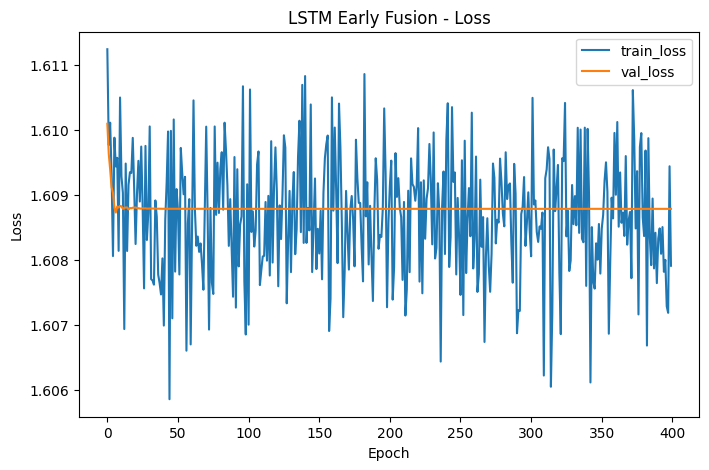

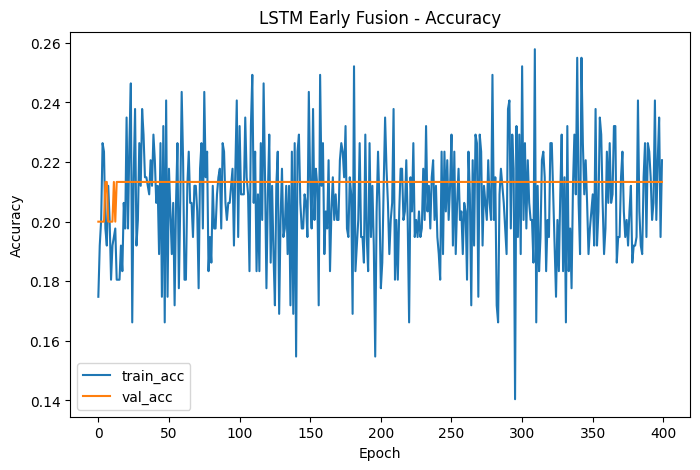

In [649]:
# ============================================
# Cell 17: plot training curves
# ============================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{MODEL_TYPE} Early Fusion - Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_TYPE} Early Fusion - Accuracy")
plt.legend()
plt.show()

In [650]:
# ============================================
# Cell 18: sanity check one batch through model
# ============================================
inputs_tuple, labels, session_ids = next(iter(train_loader))
batch = unpack_batch_inputs(inputs_tuple)
batch = move_batch_to_device(batch, DEVICE)

with torch.no_grad():
    logits = model(
        video=batch["video"],
        body=batch["body"],
        hand=batch["hand"],
    )

print("logits shape:", logits.shape)
print("labels shape:", labels.shape)
print("session ids example:", session_ids[:3])

logits shape: torch.Size([16, 5])
labels shape: torch.Size([16])
session ids example: ['session_0094', 'session_0045', 'session_0020']


Now the logger

In [651]:
# ============================================
# Cell X1: logger imports
# ============================================
import os
import json
import csv
import shutil
from datetime import datetime
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [652]:
# ============================================
# Cell X2: logger config
# ============================================
LOGGER_ROOT = "./logger"

# set this if you want a custom experiment note in folder name
RUN_NOTE = "early_fusion"

os.makedirs(LOGGER_ROOT, exist_ok=True)

In [653]:
# ============================================
# Cell X3: helper functions for logging
# ============================================
def get_modalities_tag(video_enabled, body_enabled, hand_enabled):
    tags = []
    if video_enabled:
        tags.append("video")
    if body_enabled:
        tags.append("body")
    if hand_enabled:
        tags.append("hand")
    if len(tags) == 0:
        return "none"
    return "+".join(tags)


def make_run_name(
    model_type,
    lr,
    epochs,
    video_enabled,
    body_enabled,
    hand_enabled,
    note="",
):
    modalities_tag = get_modalities_tag(video_enabled, body_enabled, hand_enabled)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    lr_str = f"{lr:.0e}" if lr < 1e-3 else str(lr).replace(".", "p")
    name_parts = [
        timestamp,
        model_type,
        f"lr_{lr_str}",
        f"ep_{epochs}",
        modalities_tag,
    ]
    if note is not None and len(str(note).strip()) > 0:
        name_parts.append(str(note).strip().replace(" ", "_"))
    return "__".join(name_parts)


def make_run_dir(
    logger_root,
    model_type,
    lr,
    epochs,
    video_enabled,
    body_enabled,
    hand_enabled,
    note="",
):
    run_name = make_run_name(
        model_type=model_type,
        lr=lr,
        epochs=epochs,
        video_enabled=video_enabled,
        body_enabled=body_enabled,
        hand_enabled=hand_enabled,
        note=note,
    )
    run_dir = os.path.join(logger_root, run_name)
    os.makedirs(run_dir, exist_ok=True)
    return run_name, run_dir


def safe_to_python(obj):
    """
    Convert objects into JSON-serializable form.
    """
    if isinstance(obj, (str, int, float, bool)) or obj is None:
        return obj
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, torch.device):
        return str(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()
    if isinstance(obj, (list, tuple)):
        return [safe_to_python(x) for x in obj]
    if isinstance(obj, dict):
        return {str(k): safe_to_python(v) for k, v in obj.items()}
    return str(obj)


def flatten_dict(d, parent_key="", sep="."):
    """
    Flatten nested dict for meta csv.
    """
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else str(k)
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)


def get_model_structure_text(model):
    return str(model)


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

In [654]:
# ============================================
# Cell X4: collect config
# ============================================
def build_run_config(model):
    total_params, trainable_params = count_parameters(model)

    config = {
        "run_info": {
            "timestamp": datetime.now().isoformat(),
            "run_note": RUN_NOTE,
        },
        "data": {
            "DATA_ROOT": DATA_ROOT,
            "LABELS": LABELS,
            "NUM_CLASSES": NUM_CLASSES,
            "VIDEO_INPUT_ENABLED": VIDEO_INPUT_ENABLED,
            "BODY_POSE_INPUT_ENABLED": BODY_POSE_INPUT_ENABLED,
            "HAND_POSE_INPUT_ENABLED": HAND_POSE_INPUT_ENABLED,
            "BODY_LANDMARK_USED": BODY_LANDMARK_USED,
            "BATCH_SIZE": BATCH_SIZE,
            "NUM_WORKERS": NUM_WORKERS,
            "VIDEO_SIZE": VIDEO_SIZE,
            "VIDEO_NORMALIZE": VIDEO_NORMALIZE,
            "VIDEO_PAD_LENGTH": VIDEO_PAD_LENGTH,
            "BODY_PAD_LENGTH": BODY_PAD_LENGTH,
            "HAND_PAD_LENGTH": HAND_PAD_LENGTH,
            "TRUNCATE_IF_LONGER": TRUNCATE_IF_LONGER,
            "REQUIRE_ALL_THREE_COMPONENTS": REQUIRE_ALL_THREE_COMPONENTS,
            "VERBOSE_SCREENING": VERBOSE_SCREENING,
            "TRAIN_RATIO": TRAIN_RATIO,
            "VAL_RATIO": VAL_RATIO,
            "TEST_RATIO": TEST_RATIO,
            "RANDOM_SEED": RANDOM_SEED,
            "STRATIFY_SPLIT": STRATIFY_SPLIT,
        },
        "model": {
            "MODEL_TYPE": MODEL_TYPE,
            "VIDEO_FEATURE_DIM": VIDEO_FEATURE_DIM,
            "USE_BODY_MLP": USE_BODY_MLP,
            "BODY_FEATURE_DIM": BODY_FEATURE_DIM,
            "USE_HAND_MLP": USE_HAND_MLP,
            "HAND_FEATURE_DIM": HAND_FEATURE_DIM,
            "LSTM_HIDDEN_DIM": LSTM_HIDDEN_DIM,
            "LSTM_NUM_LAYERS": LSTM_NUM_LAYERS,
            "LSTM_DROPOUT": LSTM_DROPOUT,
            "LSTM_BIDIRECTIONAL": LSTM_BIDIRECTIONAL,
            "CNN_HIDDEN_DIM": CNN_HIDDEN_DIM,
            "CNN_DROPOUT": CNN_DROPOUT,
            "CLASSIFIER_HIDDEN_DIM": CLASSIFIER_HIDDEN_DIM,
            "DROPOUT": DROPOUT,
            "model_structure": get_model_structure_text(model),
            "total_parameters": total_params,
            "trainable_parameters": trainable_params,
        },
        "training": {
            "DEVICE": str(DEVICE),
            "EPOCHS": EPOCHS,
            "LEARNING_RATE": LEARNING_RATE,
            "WEIGHT_DECAY": WEIGHT_DECAY,
            "USE_CLASS_WEIGHTS": USE_CLASS_WEIGHTS,
            "USE_LR_SCHEDULER": USE_LR_SCHEDULER,
        },
    }

    return safe_to_python(config)

In [655]:
# ============================================
# Cell X5: logger save functions
# ============================================
def save_json(path, obj):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(safe_to_python(obj), f, indent=2, ensure_ascii=False)


def save_text(path, text):
    with open(path, "w", encoding="utf-8") as f:
        f.write(str(text))


def save_history_csv(path, history):
    df = pd.DataFrame(history)
    df.to_csv(path, index=False)


def save_metrics_csv(path, metrics_dict):
    df = pd.DataFrame([metrics_dict])
    df.to_csv(path, index=False)


def save_predictions_csv(path, y_true, y_pred, label_names, session_ids=None):
    rows = []
    for i in range(len(y_true)):
        row = {
            "index": i,
            "y_true_idx": int(y_true[i]),
            "y_true_name": label_names[int(y_true[i])],
            "y_pred_idx": int(y_pred[i]),
            "y_pred_name": label_names[int(y_pred[i])],
        }
        if session_ids is not None and i < len(session_ids):
            row["session_id"] = session_ids[i]
        rows.append(row)

    pd.DataFrame(rows).to_csv(path, index=False)


def plot_and_save_training_curves(history, run_dir, title_prefix):
    epochs_range = list(range(1, len(history["train_loss"]) + 1))

    loss_plot_path = os.path.join(run_dir, "loss_curve.png")
    acc_plot_path = os.path.join(run_dir, "accuracy_curve.png")

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_loss"], label="train_loss")
    plt.plot(epochs_range, history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} - Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(loss_plot_path, dpi=200)
    plt.close()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_acc"], label="train_acc")
    plt.plot(epochs_range, history["val_acc"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} - Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(acc_plot_path, dpi=200)
    plt.close()

    return loss_plot_path, acc_plot_path


def save_confusion_matrix_plot(cm, label_names, run_dir, title_prefix):
    fig_path = os.path.join(run_dir, "confusion_matrix.png")

    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"{title_prefix} - Confusion Matrix")
    plt.colorbar()
    tick_marks = np.arange(len(label_names))
    plt.xticks(tick_marks, label_names, rotation=45, ha="right")
    plt.yticks(tick_marks, label_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.savefig(fig_path, dpi=200)
    plt.close()

    return fig_path


def append_meta_csv(meta_csv_path, row_dict):
    row_dict = safe_to_python(row_dict)

    if os.path.isfile(meta_csv_path):
        df_old = pd.read_csv(meta_csv_path)
        df_new = pd.DataFrame([row_dict])

        all_cols = sorted(set(df_old.columns).union(set(df_new.columns)))
        df_old = df_old.reindex(columns=all_cols)
        df_new = df_new.reindex(columns=all_cols)

        df_all = pd.concat([df_old, df_new], ignore_index=True)
        df_all.to_csv(meta_csv_path, index=False)
    else:
        pd.DataFrame([row_dict]).to_csv(meta_csv_path, index=False)

In [656]:
# ============================================
# Cell X6: evaluate with session ids
# ============================================
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support


def evaluate_loader_with_ids(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    all_preds = []
    all_labels = []
    all_session_ids = []

    with torch.no_grad():
        for inputs_tuple, labels, session_ids in loader:
            batch = unpack_batch_inputs(inputs_tuple)
            batch = move_batch_to_device(batch, device)
            labels = labels.to(device)

            logits = model(
                video=batch["video"],
                body=batch["body"],
                hand=batch["hand"],
            )

            loss = criterion(logits, labels)
            preds = torch.argmax(logits, dim=1)

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            running_correct += (preds == labels).sum().item()
            running_total += batch_size

            all_preds.extend(preds.detach().cpu().numpy().tolist())
            all_labels.extend(labels.detach().cpu().numpy().tolist())
            all_session_ids.extend(session_ids)

    avg_loss = running_loss / max(running_total, 1)
    avg_acc = running_correct / max(running_total, 1)

    return {
        "loss": avg_loss,
        "acc": avg_acc,
        "preds": all_preds,
        "labels": all_labels,
        "session_ids": all_session_ids,
    }

In [657]:
# ============================================
# Cell X7: main logger function
# ============================================
def finalize_and_log_run(
    model,
    history,
    best_model_path,
    train_metrics,
    val_metrics,
    test_metrics,
    logger_root="./logger",
    meta_csv_name="meta_runs.csv",
):
    # ----------------------------------------
    # Make run folder
    # ----------------------------------------
    run_name, run_dir = make_run_dir(
        logger_root=logger_root,
        model_type=MODEL_TYPE,
        lr=LEARNING_RATE,
        epochs=EPOCHS,
        video_enabled=VIDEO_INPUT_ENABLED,
        body_enabled=BODY_POSE_INPUT_ENABLED,
        hand_enabled=HAND_POSE_INPUT_ENABLED,
        note=RUN_NOTE,
    )

    title_prefix = (
        f"{MODEL_TYPE} | lr={LEARNING_RATE} | ep={EPOCHS} | "
        f"mods={get_modalities_tag(VIDEO_INPUT_ENABLED, BODY_POSE_INPUT_ENABLED, HAND_POSE_INPUT_ENABLED)}"
    )

    # ----------------------------------------
    # Save config
    # ----------------------------------------
    config = build_run_config(model)
    config["paths"] = {
        "run_dir": run_dir,
        "best_model_source_path": best_model_path,
    }

    save_json(os.path.join(run_dir, "config.json"), config)
    save_text(os.path.join(run_dir, "model_structure.txt"), get_model_structure_text(model))

    # ----------------------------------------
    # Save training history
    # ----------------------------------------
    save_history_csv(os.path.join(run_dir, "history.csv"), history)
    loss_plot_path, acc_plot_path = plot_and_save_training_curves(history, run_dir, title_prefix)

    # ----------------------------------------
    # Save checkpoint into run dir
    # ----------------------------------------
    checkpoint_dst = os.path.join(run_dir, "best_model.pt")
    if os.path.isfile(best_model_path):
        shutil.copy2(best_model_path, checkpoint_dst)
    else:
        torch.save(model.state_dict(), checkpoint_dst)

    # ----------------------------------------
    # Save result metrics
    # ----------------------------------------
    y_true = test_metrics["labels"]
    y_pred = test_metrics["preds"]
    session_ids = test_metrics["session_ids"]

    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    cm_path = save_confusion_matrix_plot(cm, LABELS, run_dir, title_prefix)

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=LABELS,
        digits=4,
        output_dict=True,
        zero_division=0,
    )
    save_json(os.path.join(run_dir, "classification_report.json"), report_dict)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    result_metrics = {
        "run_name": run_name,
        "train_loss_last": float(history["train_loss"][-1]),
        "train_acc_last": float(history["train_acc"][-1]),
        "val_loss_last": float(history["val_loss"][-1]),
        "val_acc_last": float(history["val_acc"][-1]),
        "test_loss": float(test_metrics["loss"]),
        "test_acc": float(test_metrics["acc"]),
        "test_precision_macro": float(precision_macro),
        "test_recall_macro": float(recall_macro),
        "test_f1_macro": float(f1_macro),
        "test_precision_weighted": float(precision_weighted),
        "test_recall_weighted": float(recall_weighted),
        "test_f1_weighted": float(f1_weighted),
    }

    save_json(os.path.join(run_dir, "result_metrics.json"), result_metrics)
    save_metrics_csv(os.path.join(run_dir, "result_metrics.csv"), result_metrics)
    save_predictions_csv(
        os.path.join(run_dir, "test_predictions.csv"),
        y_true=y_true,
        y_pred=y_pred,
        label_names=LABELS,
        session_ids=session_ids,
    )

    # Also save raw train/val metrics if you want
    save_json(os.path.join(run_dir, "train_metrics.json"), train_metrics)
    save_json(os.path.join(run_dir, "val_metrics.json"), val_metrics)
    save_json(os.path.join(run_dir, "test_metrics_full.json"), test_metrics)

    # ----------------------------------------
    # Save confusion matrix csv
    # ----------------------------------------
    cm_df = pd.DataFrame(cm, index=LABELS, columns=LABELS)
    cm_df.to_csv(os.path.join(run_dir, "confusion_matrix.csv"))

    # ----------------------------------------
    # Append meta csv
    # ----------------------------------------
    flattened_config = flatten_dict(config)
    meta_row = {
        "run_name": run_name,
        "run_dir": run_dir,
        "checkpoint_path": checkpoint_dst,
        "loss_plot_path": loss_plot_path,
        "acc_plot_path": acc_plot_path,
        "cm_plot_path": cm_path,
        **result_metrics,
        **flattened_config,
    }

    meta_csv_path = os.path.join(logger_root, meta_csv_name)
    append_meta_csv(meta_csv_path, meta_row)

    print("Run logged to:", run_dir)
    print("Meta CSV updated:", meta_csv_path)

    return {
        "run_name": run_name,
        "run_dir": run_dir,
        "checkpoint_path": checkpoint_dst,
        "meta_csv_path": meta_csv_path,
    }

In [658]:
# ============================================
# Cell X8: run this after training is finished
# ============================================
# Reload best model first, if needed
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

# Re-evaluate train / val / test with session ids
train_metrics_logged = evaluate_loader_with_ids(model, train_loader, criterion, DEVICE)
val_metrics_logged = evaluate_loader_with_ids(model, val_loader, criterion, DEVICE)
test_metrics_logged = evaluate_loader_with_ids(model, test_loader, criterion, DEVICE)

log_info = finalize_and_log_run(
    model=model,
    history=history,
    best_model_path=BEST_MODEL_PATH,
    train_metrics=train_metrics_logged,
    val_metrics=val_metrics_logged,
    test_metrics=test_metrics_logged,
    logger_root=LOGGER_ROOT,
    meta_csv_name="meta_runs.csv",
)

log_info

Run logged to: ./logger/20260320_153930__LSTM__lr_3e-04__ep_400__hand__early_fusion
Meta CSV updated: ./logger/meta_runs.csv


{'run_name': '20260320_153930__LSTM__lr_3e-04__ep_400__hand__early_fusion',
 'run_dir': './logger/20260320_153930__LSTM__lr_3e-04__ep_400__hand__early_fusion',
 'checkpoint_path': './logger/20260320_153930__LSTM__lr_3e-04__ep_400__hand__early_fusion/best_model.pt',
 'meta_csv_path': './logger/meta_runs.csv'}

In [659]:
# ============================================
# Cell X9: optional quick viewer for the meta csv
# ============================================
meta_csv_path = os.path.join(LOGGER_ROOT, "meta_runs.csv")
if os.path.isfile(meta_csv_path):
    meta_df = pd.read_csv(meta_csv_path)
    display(meta_df.tail(10))
else:
    print("No meta csv found yet.")

,acc_plot_path,checkpoint_path,cm_plot_path,data.BATCH_SIZE,data.BODY_LANDMARK_USED,data.BODY_PAD_LENGTH,data.BODY_POSE_INPUT_ENABLED,data.DATA_ROOT,data.HAND_PAD_LENGTH,data.HAND_POSE_INPUT_ENABLED,...,train_acc_last,train_loss_last,training.DEVICE,training.EPOCHS,training.LEARNING_RATE,training.USE_CLASS_WEIGHTS,training.USE_LR_SCHEDULER,training.WEIGHT_DECAY,val_acc_last,val_loss_last
0,./logger/20260320_152516__CNN__lr_1e-04__ep_40...,./logger/20260320_152516__CNN__lr_1e-04__ep_40...,./logger/20260320_152516__CNN__lr_1e-04__ep_40...,16,"[5, 6, 7, 8, 9, 10, 11, 12]",64,False,hand_dummy/data,64,True,...,0.994269,0.067738,cuda,400,0.0001,False,True,0.0001,0.960000,0.158404
1,./logger/20260320_152647__CNN__lr_1e-04__ep_40...,./logger/20260320_152647__CNN__lr_1e-04__ep_40...,./logger/20260320_152647__CNN__lr_1e-04__ep_40...,16,"[5, 6, 7, 8, 9, 10, 11, 12]",64,True,hand_dummy/data,64,False,...,0.945559,0.282922,cuda,400,0.0001,False,True,0.0001,0.960000,0.227696
2,./logger/20260320_152934__CNN__lr_1e-04__ep_40...,./logger/20260320_152934__CNN__lr_1e-04__ep_40...,./logger/20260320_152934__CNN__lr_1e-04__ep_40...,16,"[5, 6, 7, 8, 9, 10, 11, 12]",64,True,hand_dummy/data,64,True,...,0.979943,0.084508,cuda,400,0.0001,False,True,0.0001,0.986667,0.086058
3,./logger/20260320_153137__CNN__lr_0p01__ep_400...,./logger/20260320_153137__CNN__lr_0p01__ep_400...,./logger/20260320_153137__CNN__lr_0p01__ep_400...,16,"[5, 6, 7, 8, 9, 10, 11, 12]",64,True,hand_dummy/data,64,True,...,0.888252,0.324791,cuda,400,0.0100,False,True,0.0001,0.933333,0.180644
4,./logger/20260320_153322__CNN__lr_0p01__ep_400...,./logger/20260320_153322__CNN__lr_0p01__ep_400...,./logger/20260320_153322__CNN__lr_0p01__ep_400...,16,"[5, 6, 7, 8, 9, 10, 11, 12]",64,False,hand_dummy/data,64,True,...,0.982808,0.076535,cuda,400,0.0100,False,True,0.0001,0.933333,0.205436
5,./logger/20260320_153442__CNN__lr_0p01__ep_400...,./logger/20260320_153442__CNN__lr_0p01__ep_400...,./logger/20260320_153442__CNN__lr_0p01__ep_400...,16,"[5, 6, 7, 8, 9, 10, 11, 12]",64,True,hand_dummy/data,64,False,...,0.816619,0.526514,cuda,400,0.0100,False,True,0.0001,0.893333,0.392276
6,./logger/20260320_153729__LSTM__lr_3e-04__ep_4...,./logger/20260320_153729__LSTM__lr_3e-04__ep_4...,./logger/20260320_153729__LSTM__lr_3e-04__ep_4...,16,"[5, 6, 7, 8, 9, 10, 11, 12]",64,True,hand_dummy/data,64,False,...,0.352436,1.466483,cuda,400,0.0003,False,True,0.0001,0.373333,1.515263
7,./logger/20260320_153930__LSTM__lr_3e-04__ep_4...,./logger/20260320_153930__LSTM__lr_3e-04__ep_4...,./logger/20260320_153930__LSTM__lr_3e-04__ep_4...,16,"[5, 6, 7, 8, 9, 10, 11, 12]",64,False,hand_dummy/data,64,True,...,0.220630,1.607907,cuda,400,0.0003,False,True,0.0001,0.213333,1.608784
